In [1]:
import tensorflow as tf

tf.config.list_physical_devices('GPU')


2024-10-07 16:53:47.220824: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-07 16:53:48.344243: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-07 16:53:49.607672: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2024-10-07 16:53:51.569071: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

2024-10-07 16:53:51.811999: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-07 16:53:51.812042: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import polars as pl
import tensorflow as tf
import numpy as np

NUM_OF_TOKENS = 12
NUM_OF_CNN_TOKENS = 8
BATCH_SIZE = 32


def prepare_data_lazy(file_path, num_prev=NUM_OF_TOKENS-1, cnn_tokens=NUM_OF_CNN_TOKENS, batch_size=BATCH_SIZE, shuffle=False):
    """
    Prepare data for the transformer model using Polars and lazy loading,
    with shuffling done by randomly selecting indices, and processing in batches.
    
    Args:
        file_path (str): Path to the CSV file.
        num_prev (int): Number of previous time frames to include.
        shuffle (bool): Whether to shuffle the data.
        batch_size (int): Number of rows to process in each batch.
    
    Yields:
        input_tensor (tf.Tensor): Tensor with shape (batch_size, num_prev + 1, 4).
        target_tensor (tf.Tensor): Tensor with shape (batch_size,).
    """
    # Load CSV lazily with Polars
    df_lazy = pl.scan_csv(file_path).select(['open_normalized', 'high_normalized', 'low_normalized', 'close_normalized', 'target'])

    # Collect the dataframe and determine total number of rows
    df_collected = df_lazy.collect()
    total_rows = df_collected.shape[0]

    # Create an array of indices to use for shuffling
    indices = list(range(num_prev, total_rows))
    # Shuffle indices if required
    if shuffle:
        np.random.shuffle(indices)

    input_list = []
    cnn_input_list = []
    target_list = []

    # Process the data in batches
    while indices:
        batch_indices = [indices.pop(0) for _ in range(min(batch_size, len(indices)))]

        for idx in batch_indices:
            # Fetch the previous `num_prev + 1` rows for the input based on the current index
            input_rows = df_collected[idx - num_prev:idx + 1, :-1].to_numpy()  # Exclude 'target' for input
            target_value = df_collected[idx, -1]  # Get 'target' for the target

            # Convert target to 0 if it's not 1
            target_value = 1 if target_value == 1 else 0

            input_list.append(input_rows)
            cnn_input_list.append(input_rows[:cnn_tokens])  # Select the first `cnn_tokens` rows for the CNN input
            target_list.append(target_value)

        # Convert lists to NumPy arrays
        input_array = np.array(input_list)
        cnn_input_array = np.array(cnn_input_list)
        cnn_input_array = np.expand_dims(cnn_input_array, axis=-1)
        target_array = np.array(target_list)

        # Convert NumPy arrays to TensorFlow tensors
        input_tensor = tf.convert_to_tensor(input_array, dtype=tf.float32)
        cnn_tensor = tf.convert_to_tensor(cnn_input_array, dtype=tf.float32)
        target_tensor = tf.convert_to_tensor(target_array, dtype=tf.int32)

        yield (input_tensor, cnn_tensor), target_tensor

        # Reset lists for the next batch
        input_list.clear()
        cnn_input_list.clear()
        target_list.clear()




# Rest of your model building and training code remains unchanged
def create_dataset_generator(file_path, batch_size=BATCH_SIZE, shuffle=False, repeat=False):
    dataset = tf.data.Dataset.from_generator(
        lambda: prepare_data_lazy(file_path, batch_size=batch_size, shuffle=shuffle),
        output_signature=(
            (tf.TensorSpec(shape=(None, NUM_OF_TOKENS, 4), dtype=tf.float32),
             tf.TensorSpec(shape=(None, NUM_OF_CNN_TOKENS, 4, 1), dtype=tf.float32)),
            tf.TensorSpec(shape=(None,), dtype=tf.int32)
        )
    )
    if repeat:
        dataset = dataset.repeat()
    return dataset


In [3]:
from tensorflow.keras import backend as K
import tensorflow as tf

# Custom loss function influenced by precision
def precision_influenced_loss(y_true, y_pred):
    # Ensure both y_true and y_pred are float32
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)
    
    # Binary Crossentropy loss
    bce_loss = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    # Precision metric
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())

    # Introduce a penalty term based on precision
    precision_penalty = 1.0 - precision

    # Combine binary cross-entropy with precision penalty

    loss = bce_loss + 0.2 * precision_penalty  # Adjust 0.5 as a weighting factor

    return loss



In [4]:
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout
from tensorflow.keras.models import Model
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


# Positional Encoding remains the same
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, maxlen, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(maxlen, d_model)

    def positional_encoding(self, maxlen, d_model):
        import numpy as np
        positions = np.arange(maxlen)[:, np.newaxis]
        angles = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (angles // 2)) / np.float32(d_model))
        angle_rads = positions * angle_rates

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embed_dim)]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)



In [5]:
import tensorflow as tf

def auc_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    
    # Approximate ranking using pairwise comparisons
    n = tf.shape(y_true)[0]
    pair_wise_diff = y_pred[:, None] - y_pred[None, :]
    
    # Use sigmoid to approximate step function
    pair_wise_rank = tf.sigmoid(pair_wise_diff)
    
    # Compute AUC
    pos_mask = y_true[:, None] * (1 - y_true[None, :])
    neg_mask = (1 - y_true[:, None]) * y_true[None, :]
    auc = tf.reduce_sum(pair_wise_rank * pos_mask) / (tf.reduce_sum(pos_mask) + 1e-8)
    
    
    # Return negative AUC as we want to maximize it
    return 1.0 - auc

In [6]:
precision_metric = tf.keras.metrics.Precision()

def precision_loss(y_true, y_pred):
    # Reset the metric's state
    precision_metric.reset_state()
    
    # Update the state with current batch's y_true and y_pred
    precision_metric.update_state(y_true, y_pred)
    
    # Return 1 - precision to minimize the loss
    return 1 - precision_metric.result()

2024-10-07 16:53:52.075837: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-07 16:53:52.076032: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-07 16:53:52.076066: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-07 16:53:52.237614: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-07 16:53:52.237673: I external/local_xla/xla/stream_executor

In [7]:
def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    precision = precision_loss(y_true, y_pred)
    auc = auc_loss(y_true, y_pred)
    return bce + 0.2*auc + 0.5*precision


In [8]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Concatenate, Reshape

def build_combined_model(transformer_input_shape, cnn_input_shape, d_model=64, num_heads=2, ff_dim=128, num_layers=4):
    # Transformer branch
    transformer_inputs = Input(shape=transformer_input_shape)
    x_transformer = Dense(d_model)(transformer_inputs)
    x_transformer = PositionalEncoding(transformer_input_shape[0], d_model)(x_transformer)
    for _ in range(num_layers):
        x_transformer = TransformerBlock(d_model, num_heads, ff_dim)(x_transformer, training=True)
    x_transformer = Dense(32, activation='relu')(x_transformer)
    x_transformer = tf.keras.layers.GlobalAveragePooling1D()(x_transformer)
    x_transformer = Dropout(0.1)(x_transformer)
    x_transformer = Dense(16, activation='relu')(x_transformer)

    # CNN branch
    cnn_inputs = Input(shape=cnn_input_shape)
# First Block: Two convolutional layers followed by a max pooling layer
    x_cnn = Conv2D(16, (1, 4), activation='relu', padding='same', strides=4)(cnn_inputs)
    x_cnn = AveragePooling2D((1, 4), padding='same', strides=4)(x_cnn)

    # Second Block: Two convolutional layers followed by a max pooling layer
    x_cnn = Conv2D(8, (1, 4), activation='relu', padding='same')(x_cnn)
    x_cnn = Conv2D(8, (1, 4), activation='relu', padding='same')(x_cnn)
    x_cnn = MaxPooling2D((1, 2), padding='same')(x_cnn)

    # Flatten the output to feed into a Dense layer
    x_cnn = Flatten()(x_cnn)

    # Dense layers with Dropout
    x_cnn = Dense(128, activation='relu')(x_cnn)
    x_cnn = Dropout(0.1)(x_cnn)  # Add dropout for regularization


    # Merge both branches
    combined = Concatenate()([x_transformer, x_cnn])
    combined = Dense(64, activation='relu')(combined)
    combined = Dropout(0.1)(combined)
    
    # Output layer for binary classification
    outputs = Dense(1, activation='sigmoid')(combined)

    model = Model(inputs=[transformer_inputs, cnn_inputs], outputs=outputs)
    return model

# Define input shapes
transformer_input_shape = (NUM_OF_TOKENS, 4)  # 11 tokens for transformer
cnn_input_shape = (NUM_OF_CNN_TOKENS, 4, 1)  # 11 tokens reshaped for CNN

model = build_combined_model(transformer_input_shape, cnn_input_shape, d_model=32, ff_dim=64, num_heads=2, num_layers=2)


# Compile the combined model
model.compile(optimizer='adam', 
              loss=combined_loss, 
              metrics=['accuracy', tf.keras.metrics.AUC(), tf.keras.metrics.Precision()])


In [9]:
def get_total_rows(file_path):
    # Count the total number of rows in the CSV file
    df_lazy = pl.scan_csv(file_path)
    return df_lazy.collect().shape[0]

In [10]:
train_file = 'recent_data/BTCUSD/train.csv'
val_file = 'recent_data/BTCUSD/val.csv'
test_file = 'recent_data/BTCUSD/test.csv'

train_dataset= create_dataset_generator(train_file, shuffle=True, repeat=True).prefetch(tf.data.AUTOTUNE)
val_dataset = create_dataset_generator(val_file, repeat=True).prefetch(tf.data.AUTOTUNE)
test_dataset = create_dataset_generator(test_file).prefetch(tf.data.AUTOTUNE)

train_steps_per_epoch = get_total_rows(train_file)//BATCH_SIZE
val_steps_per_epoch = get_total_rows(val_file)//BATCH_SIZE
test_steps_per_epoch = get_total_rows(test_file)//BATCH_SIZE


In [11]:
class_weight = {
    0:1,
    1:6
}
early_stopping = EarlyStopping(monitor='val_auc', 
                               patience=5, # Stops if there's no improvement in precision for 5 epochs
                               mode='max', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_comb_model.keras', 
                                   monitor='val_auc', 
                                   save_best_only=True, 
                                   mode='max', 
                                   verbose=1)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=20,
    steps_per_epoch = train_steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=val_steps_per_epoch,
    class_weight=class_weight,
    callbacks=[early_stopping, model_checkpoint]
)


# Load the best model after training
model.load_weights('best_comb_model.keras')

Epoch 1/20


I0000 00:00:1728312842.319943  306531 service.cc:145] XLA service 0x7f8e4400d720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728312842.320121  306531 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2024-10-07 16:54:03.066313: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-07 16:54:03.884111: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1728312849.601228  306663 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_15', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1728312851.316963  306649 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_17', 8 bytes spill stores, 8 bytes spill loads



   5/6137 ━━━━━━━━━━━━━━━━━━━━ 3:44 37ms/step - accuracy: 0.6472 - auc: 0.5801 - loss: 1.9343 - precision_1: 0.1290  

I0000 00:00:1728312857.674923  306531 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6136/6137 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6016 - auc: 0.7516 - loss: 1.5877 - precision_1: 0.2017
Epoch 1: val_auc improved from -inf to 0.88009, saving model to best_comb_model.keras
6137/6137 ━━━━━━━━━━━━━━━━━━━━ 198s 28ms/step - accuracy: 0.6017 - auc: 0.7516 - loss: 1.5876 - precision_1: 0.2017 - val_accuracy: 0.6029 - val_auc: 0.8801 - val_loss: 1.1646 - val_precision_1: 0.2275
Epoch 2/20
6136/6137 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7857 - auc: 0.8853 - loss: 1.2326 - precision_1: 0.3374
Epoch 2: val_auc improved from 0.88009 to 0.89542, saving model to best_comb_model.keras
6137/6137 ━━━━━━━━━━━━━━━━━━━━ 184s 28ms/step - accuracy: 0.7857 - auc: 0.8853 - loss: 1.2326 - precision_1: 0.3374 - val_accuracy: 0.8088 - val_auc: 0.8954 - val_loss: 0.8338 - val_precision_1: 0.3687
Epoch 3/20
6137/6137 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7881 - auc: 0.8899 - loss: 1.2069 - precision_1: 0.3381
Epoch 3: val_auc did not improve from 0.89542
6137/6137 ━

In [12]:
test_dataset = create_dataset_generator('recent_data/BTCUSD/test.csv', batch_size=32).prefetch(tf.data.AUTOTUNE)

In [13]:
# Get predictions as probabilities
predictions = model.predict(test_dataset, steps=test_steps_per_epoch)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)


1315/1315 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step


In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
# Predict the classes for the test dataset
y_true = []
y_pred = []

for input_tensor, target_tensor in test_dataset:
#     predictions = model.predict(input_tensor)
#     predicted_classes = np.argmax(predictions, axis=1)  # Get the class with the highest score
    y_true.extend(target_tensor.numpy()) 

2024-10-07 18:04:59.452000: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
len(predicted_class), len(y_true)

(42078, 42078)

In [17]:
predicted_class = (predictions > 0.5).astype(int)


Confusion Matrix:
 [[30536  7188]
 [  104  4250]]


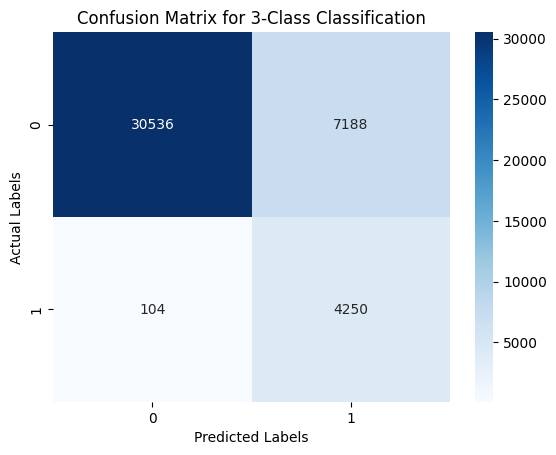

In [18]:
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Optionally: Visualize the confusion matrix using a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for 3-Class Classification')
plt.show()